In [ ]:
import os
import glob
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

# Đường dẫn tập dữ liệu bạn cung cấp
DATA_DIR = '/kaggle/input/datasets/kaushalbora18/penn-action-dataset/Penn_Action'
LABELS_DIR = os.path.join(DATA_DIR, 'labels')
FRAMES_DIR = os.path.join(DATA_DIR, 'frames')

# Kiểm tra xem đường dẫn có tồn tại không
print(f"Thư mục Data tồn tại: {os.path.exists(DATA_DIR)}")
print(f"Thư mục Labels tồn tại: {os.path.exists(LABELS_DIR)}")
print(f"Thư mục Frames tồn tại: {os.path.exists(FRAMES_DIR)}")

Thư mục Data tồn tại: True
Thư mục Labels tồn tại: True
Thư mục Frames tồn tại: True


In [ ]:
# Lấy danh sách tất cả file .mat
mat_files = sorted(glob.glob(os.path.join(LABELS_DIR, '*.mat')))
data_info = []

for mat_file in mat_files:
    video_id = os.path.basename(mat_file).replace('.mat', '')

    try:
        # Load file mat
        mat_content = scipy.io.loadmat(mat_file)

        # Trích xuất nhãn hành động (xử lý định dạng chuỗi trong file mat)
        action = mat_content['action'][0] if 'action' in mat_content else 'unknown'
        if isinstance(action, np.ndarray) and len(action) > 0:
            action = action[0]

        # Trích xuất số lượng khung hình
        nframes = mat_content['nframes'][0][0] if 'nframes' in mat_content else 0

        data_info.append({
            'video_id': video_id,
            'action': str(action),
            'nframes': int(nframes)
        })
    except Exception as e:
        print(f"Lỗi đọc file {video_id}: {e}")

df = pd.DataFrame(data_info)
print(f"Tổng số video quét được: {len(df)}")
df.head()

Tổng số video quét được: 2326


,video_id,action,nframes
0,0001,baseball_pitch,151
1,0002,baseball_pitch,80
2,0003,baseball_pitch,85
3,0004,baseball_pitch,82
4,0005,baseball_pitch,48


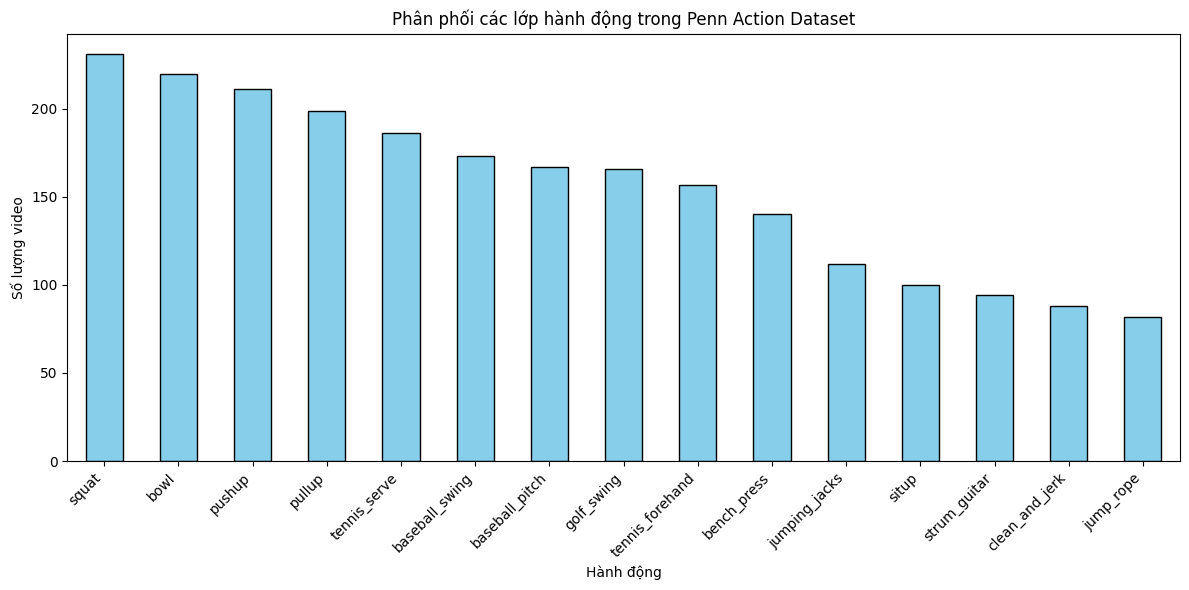


Số lượng video thuộc nhóm tập thể dục: 1163 / 2326
Chi tiết số lượng từng bài tập:
action
squat             231
pushup            211
pullup            199
bench_press       140
jumping_jacks     112
situp             100
clean_and_jerk     88
jump_rope          82
Name: count, dtype: int64

Số khung hình trung bình: 83.3
Số khung hình ít nhất: 18
Số khung hình nhiều nhất: 663


In [ ]:
# 1. Vẽ biểu đồ phân phối toàn bộ hành động
plt.figure(figsize=(12, 6))
df['action'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Phân phối các lớp hành động trong Penn Action Dataset')
plt.xlabel('Hành động')
plt.ylabel('Số lượng video')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Lọc subset các bài tập thể dục (Exercise subset)
# Tham khảo các nhãn có trong Penn Action
exercise_classes = [
    'bench_press', 'clean_and_jerk', 'jump_rope',
    'jumping_jacks', 'pullup', 'pushup', 'situp', 'squat'
]

df_exercise = df[df['action'].isin(exercise_classes)].copy()

print(f"\nSố lượng video thuộc nhóm tập thể dục: {len(df_exercise)} / {len(df)}")
print("Chi tiết số lượng từng bài tập:")
print(df_exercise['action'].value_counts())

# Phân tích độ dài khung hình (quan trọng cho ST-GCN)
print(f"\nSố khung hình trung bình: {df_exercise['nframes'].mean():.1f}")
print(f"Số khung hình ít nhất: {df_exercise['nframes'].min()}")
print(f"Số khung hình nhiều nhất: {df_exercise['nframes'].max()}")

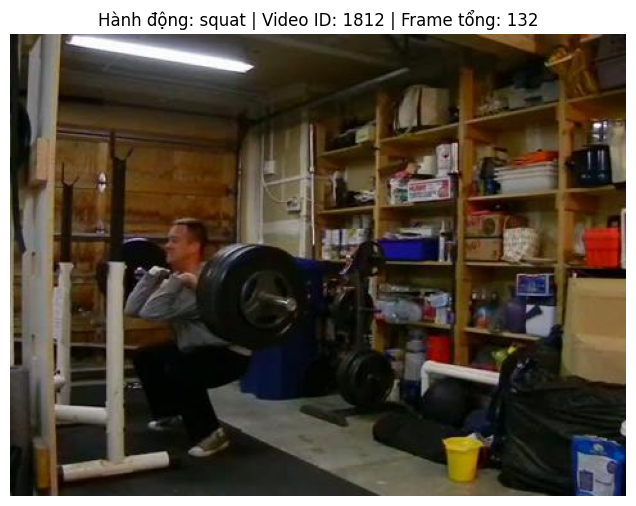

In [ ]:
# Chọn ngẫu nhiên 1 video từ nhóm tập thể dục
sample_row = df_exercise.sample(1).iloc[0]
sample_vid = sample_row['video_id']
sample_action = sample_row['action']

# Đường dẫn đến thư mục chứa frames của video đó
sample_frames_dir = os.path.join(FRAMES_DIR, sample_vid)
frame_files = sorted(glob.glob(os.path.join(sample_frames_dir, '*.jpg')))

if len(frame_files) > 0:
    # Đọc frame ở giữa video (thường là khoảnh khắc động tác rõ nhất)
    mid_frame_path = frame_files[len(frame_files) // 2]
    img = cv2.imread(mid_frame_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title(f"Hành động: {sample_action} | Video ID: {sample_vid} | Frame tổng: {len(frame_files)}")
    plt.axis('off')
    plt.show()
else:
    print(f"Không tìm thấy ảnh nào trong thư mục {sample_frames_dir}")

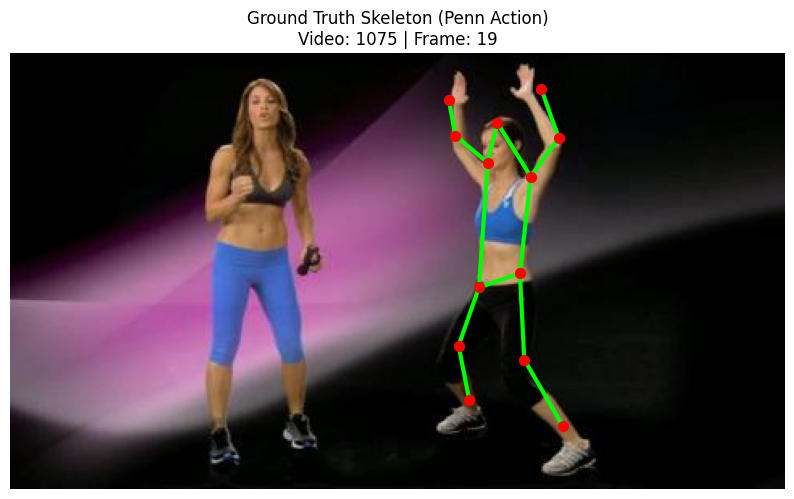

In [ ]:
import os
import cv2
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# 1. Đường dẫn mẫu (Sử dụng lại video 1075, frame thứ 18 như ví dụ trước)
DATA_DIR = '/kaggle/input/datasets/kaushalbora18/penn-action-dataset/Penn_Action'
video_id = '1075'
frame_idx = 18 # Frame 18 tương ứng index 17 trong mảng (vì mảng bắt đầu từ 0)

img_path = os.path.join(DATA_DIR, 'frames', video_id, f'{frame_idx + 1:06d}.jpg')
mat_path = os.path.join(DATA_DIR, 'labels', f'{video_id}.mat')

# 2. Định nghĩa các cặp nối khớp (Bones) cho 13 khớp của Penn Action
# Thứ tự 13 khớp: 0:head, 1:l_sho, 2:r_sho, 3:l_elb, 4:r_elb, 5:l_wri, 6:r_wri,
# 7:l_hip, 8:r_hip, 9:l_kne, 10:r_kne, 11:l_ank, 12:r_ank
penn_action_bones = [
    (0, 1), (0, 2),               # Đầu nối với vai
    (1, 3), (3, 5),               # Tay trái (vai-khuỷu-cổ tay)
    (2, 4), (4, 6),               # Tay phải (vai-khuỷu-cổ tay)
    (1, 7), (2, 8),               # Vai nối xuống hông
    (7, 8),                       # Nối 2 hông
    (7, 9), (9, 11),              # Chân trái (hông-đầu gối-cổ chân)
    (8, 10), (10, 12)             # Chân phải (hông-đầu gối-cổ chân)
]

# 3. Đọc dữ liệu
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mat_data = scipy.io.loadmat(mat_path)

# Trích xuất ma trận tọa độ X, Y và độ hiển thị (visibility)
# Kích thước ma trận gốc: (Số frames, 13)
x_coords = mat_data['x'][frame_idx]
y_coords = mat_data['y'][frame_idx]
visibility = mat_data['visibility'][frame_idx] # Thường 1 là thấy rõ, -1 hoặc 0 là bị che

# 4. Trực quan hóa
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)

# Vẽ các đoạn thẳng nối khớp (Bones)
for bone in penn_action_bones:
    partA, partB = bone
    # Chỉ vẽ nếu cả 2 khớp đều hiển thị (visibility > 0)
    if visibility[partA] > 0 and visibility[partB] > 0:
        plt.plot([x_coords[partA], x_coords[partB]],
                 [y_coords[partA], y_coords[partB]],
                 color='lime', linewidth=3)

# Vẽ các điểm khớp (Joints)
for i in range(len(x_coords)):
    if visibility[i] > 0:
        plt.scatter(x_coords[i], y_coords[i], color='red', s=50, zorder=5)
        # Bỏ comment dòng dưới nếu muốn hiển thị số thứ tự của từng khớp
        # plt.text(x_coords[i] + 3, y_coords[i] + 3, str(i), color='white', fontsize=10,
        #          bbox=dict(facecolor='black', alpha=0.5, pad=1))

plt.title(f"Ground Truth Skeleton (Penn Action)\nVideo: {video_id} | Frame: {frame_idx + 1}")
plt.axis('off')
plt.show()

In [ ]:
import numpy as np

def add_virtual_center_joint(keypoints):
    """
    keypoints: mảng numpy có kích thước (Frames, 13, 2) chứa tọa độ X, Y
    """
    # Lấy tọa độ của 4 khớp tạo thành hình chữ nhật thân người
    l_sho, r_sho = keypoints[:, 1, :], keypoints[:, 2, :]
    l_hip, r_hip = keypoints[:, 7, :], keypoints[:, 8, :]

    # Tính trọng tâm (Trung bình cộng của 4 điểm)
    center_joint = (l_sho + r_sho + l_hip + r_hip) / 4.0

    # Mở rộng chiều để ghép vào mảng gốc: (Frames, 1, 2)
    center_joint = center_joint[:, np.newaxis, :]

    # Ghép khớp ảo vào cuối mảng gốc -> Kích thước mới: (Frames, 14, 2)
    new_keypoints = np.concatenate((keypoints, center_joint), axis=1)

    return new_keypoints

# Giả sử x_coords và y_coords (kích thước [Frames, 13]) lấy từ file .mat
# Tạo mảng dummy để test:
# dummy_frames = np.zeros((35, 13, 2))
# updated_frames = add_virtual_center_joint(dummy_frames)
# print(updated_frames.shape) # Kết quả: (35, 14, 2)

In [ ]:
import torch
import numpy as np

class Graph_PennAction_14Nodes():
    def __init__(self):
        self.num_node = 14
        self.center_node = 13 # Khớp ảo vừa tạo làm trọng tâm

        # Cạnh cũ (13 khớp)
        self.edges = [
            (0, 1), (0, 2), (1, 3), (3, 5), (2, 4), (4, 6),
            (1, 7), (2, 8), (7, 8), (7, 9), (9, 11), (8, 10), (10, 12)
        ]

        # Thêm cạnh nối khớp ảo (13) với 4 góc của hình chữ nhật thân người
        self.edges.extend([(1, 13), (2, 13), (7, 13), (8, 13)])

        self.A = self.get_spatial_partition_matrix()

    def get_hop_distance(self):
        # Tính khoảng cách số bước nhảy (hop) giữa các khớp trên đồ thị
        A = np.zeros((self.num_node, self.num_node))
        for i, j in self.edges:
            A[j, i] = 1
            A[i, j] = 1

        hop_dis = np.zeros((self.num_node, self.num_node)) + np.inf
        # Duyệt tối đa 14 bước để tìm đường đi ngắn nhất
        transfer_mat = [np.linalg.matrix_power(A, d) for d in range(self.num_node)]
        arrive_mat = (np.stack(transfer_mat) > 0)
        for d in range(self.num_node - 1, -1, -1):
            hop_dis[arrive_mat[d]] = d
        return hop_dis

    def get_spatial_partition_matrix(self):
        # Lấy ma trận khoảng cách
        hop_dis = self.get_hop_distance()

        # Tính khoảng cách từ tất cả các điểm về trọng tâm (Center node)
        node_traversal_rate = hop_dis[self.center_node]

        # Khởi tạo ma trận A với 3 luồng (3, 14, 14)
        A = np.zeros((3, self.num_node, self.num_node))

        for i, j in self.edges:
            # Luôn cho phép tự nối chính nó (Self-loop)
            A[0, i, i] = 1
            A[0, j, j] = 1

            # Chiến lược phân hoạch:
            if node_traversal_rate[i] > node_traversal_rate[j]:
                # j gần trọng tâm hơn i -> j là hướng tâm của i
                A[1, j, i] = 1
                A[2, i, j] = 1
            elif node_traversal_rate[i] < node_traversal_rate[j]:
                # i gần trọng tâm hơn j -> i là hướng tâm của j
                A[1, i, j] = 1
                A[2, j, i] = 1
            else:
                # Cùng khoảng cách đến trọng tâm
                A[0, i, j] = 1
                A[0, j, i] = 1

        # Chuẩn hóa ma trận (tránh bùng nổ gradient khi train)
        for i in range(3):
            D = np.diag(np.sum(A[i], axis=1))
            # Xử lý chia cho 0
            D_inv = np.zeros_like(D)
            D_inv[D > 0] = 1.0 / D[D > 0]
            A[i] = np.dot(A[i], D_inv)

        return torch.tensor(A, dtype=torch.float32)

# Test thử ma trận
graph = Graph_PennAction_14Nodes()
print(f"Kích thước ma trận kề A chuẩn: {graph.A.shape}")
# Kết quả mong đợi: torch.Size([3, 14, 14])

Kích thước ma trận kề A chuẩn: torch.Size([3, 14, 14])


In [ ]:
import torch
import torch.nn as nn

class STGCN_Block(nn.Module):
    def __init__(self, in_channels, out_channels, A, stride=1, residual=True):
        super().__init__()
        # A lúc này có kích thước (3, V, V)
        self.spatial_kernel_size = A.size(0)
        self.A = nn.Parameter(A, requires_grad=False)

        # 1. Spatial GCN chuẩn: in_channels -> ra (out_channels * 3) để tương tác với 3 ma trận
        self.gcn_conv = nn.Conv2d(in_channels, out_channels * self.spatial_kernel_size, kernel_size=1)

        # 2. Temporal TCN (như cũ, kernel 9x1)
        self.tcn_conv = nn.Conv2d(out_channels, out_channels, kernel_size=(9, 1),
                                  padding=(4, 0), stride=(stride, 1))

        # 3. Residual
        if not residual:
            self.residual = lambda x: 0
        elif (in_channels == out_channels) and (stride == 1):
            self.residual = lambda x: x
        else:
            self.residual = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride, 1))

        self.relu = nn.ReLU()

    def forward(self, x):
        res = self.residual(x)
        N, C, T, V = x.size()

        # --- SPATIAL CONVOLUTION CHUẨN ---
        x = self.gcn_conv(x) # (N, out_channels * 3, T, V)

        # Tách ra 3 luồng để nhân với 3 ma trận A (Root, Centripetal, Centrifugal)
        x = x.view(N, self.spatial_kernel_size, -1, T, V) # (N, 3, out_channels, T, V)

        # Dùng einsum để nhân từng đồ thị con với đặc trưng tương ứng
        x = torch.einsum('nkctv,kvw->nctw', (x, self.A)) # (N, out_channels, T, V)

        # --- TEMPORAL CONVOLUTION ---
        x = self.tcn_conv(x)

        return self.relu(x + res)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class Model_STGCN(nn.Module):
    def __init__(self, num_classes=8, in_channels=2):
        super().__init__()
        # Khởi tạo đồ thị Penn Action
        self.graph = Graph_PennAction_14Nodes()
        A = self.graph.A

        # Data Normalization
        self.data_bn = nn.BatchNorm1d(in_channels * self.graph.num_node)

        # Các lớp ST-GCN (Thiết kế tinh gọn cho tập dữ liệu nhỏ)
        self.st_gcn_networks = nn.ModuleList([
            STGCN_Block(in_channels, 64, A, residual=False),
            STGCN_Block(64, 64, A),
            STGCN_Block(64, 128, A, stride=2), # Giảm số frame đi một nửa
            STGCN_Block(128, 128, A),
            STGCN_Block(128, 256, A, stride=2),
            STGCN_Block(256, 256, A)
        ])

        # Fully Connected Layer để phân loại
        self.fcn = nn.Conv2d(256, num_classes, kernel_size=1)

    def forward(self, x):
        # Kích thước đầu vào chuẩn của ST-GCN: (Batch, Channels, Frames, Joints, Persons)
        N, C, T, V, M = x.size()

        # Chuẩn hóa đầu vào
        x = x.permute(0, 4, 3, 1, 2).contiguous().view(N, M * V * C, T)
        x = self.data_bn(x)
        x = x.view(N, M, V, C, T).permute(0, 1, 3, 4, 2).contiguous().view(N * M, C, T, V)

        # Chạy qua các khối ST-GCN
        for gcn in self.st_gcn_networks:
            x = gcn(x)

        # Global Average Pooling (Lấy đặc trưng trung bình toàn cục)
        x = F.avg_pool2d(x, x.size()[2:])
        x = x.view(N, M, -1, 1, 1).mean(dim=1)

        # Đưa ra dự đoán
        x = self.fcn(x)
        x = x.view(x.size(0), -1)

        return x


In [ ]:

# Chạy thử để kiểm tra luồng dữ liệu (Sanity Check)
if __name__ == '__main__':
    # Giả lập đầu vào: Batch=4, Channels=2 (X,Y), Frames=64, Joints=13, Persons=1
    dummy_input = torch.randn(4, 2, 64, 14, 1)
    model = Model_STGCN(num_classes=8) # 8 lớp bài tập thể dục
    output = model(dummy_input)
    print(f"Kích thước tensor đầu ra: {output.shape} -> (Batch Size, Số lớp hành động)")

Kích thước tensor đầu ra: torch.Size([4, 8]) -> (Batch Size, Số lớp hành động)


In [ ]:
import os
import glob
import scipy.io
import numpy as np

# 1. THIẾT LẬP THÔNG SỐ VÀ ĐƯỜNG DẪN
DATA_DIR = '/kaggle/input/datasets/kaushalbora18/penn-action-dataset/Penn_Action'
LABELS_DIR = os.path.join(DATA_DIR, 'labels')

TARGET_FRAMES = 64
NUM_JOINTS_ORIG = 13
NUM_JOINTS_NEW = 14
CHANNELS = 2 # X, Y
NUM_PERSONS = 1

# Các lớp bài tập thể dục và dictionary ánh xạ sang ID (0 đến 7)
exercise_classes = [
    'bench_press', 'clean_and_jerk', 'jump_rope', 'jumping_jacks',
    'pullup', 'pushup', 'situp', 'squat'
]
class_to_id = {cls_name: idx for idx, cls_name in enumerate(exercise_classes)}

# 2. CÁC HÀM XỬ LÝ LÕI

def add_virtual_center_joint(kpts):
    """ Thêm khớp trọng tâm (số 13) vào mảng (Frames, 13, 2) """
    l_sho, r_sho = kpts[:, 1, :], kpts[:, 2, :]
    l_hip, r_hip = kpts[:, 7, :], kpts[:, 8, :]

    center = (l_sho + r_sho + l_hip + r_hip) / 4.0
    center = center[:, np.newaxis, :] # Mở rộng chiều thành (Frames, 1, 2)

    return np.concatenate((kpts, center), axis=1) # Trả về (Frames, 14, 2)

def temporal_align(kpts, target_frames):
    """ Ép độ dài video về đúng target_frames bằng Uniform Sampling/Padding """
    T = kpts.shape[0]
    if T == target_frames:
        return kpts

    # Tạo chỉ số nội suy (lấy mẫu đều đặn các frame)
    # Ví dụ: video 30 frames -> nhân bản một số frame; video 100 frames -> nhảy cóc
    indices = np.linspace(0, T - 1, target_frames).astype(int)
    return kpts[indices]

# 3. VÒNG LẶP XỬ LÝ TOÀN BỘ FILE .MAT

all_data = []
all_labels = []

mat_files = sorted(glob.glob(os.path.join(LABELS_DIR, '*.mat')))
print(f"Bắt đầu quét {len(mat_files)} files...")

for mat_file in mat_files:
    try:
        mat_data = scipy.io.loadmat(mat_file)

        # Lấy nhãn hành động
        action = mat_data['action'][0] if 'action' in mat_data else 'unknown'
        if isinstance(action, np.ndarray) and len(action) > 0:
            action = action[0]
        action = str(action)

        # Chỉ xử lý nếu thuộc 8 bài tập thể dục
        if action not in exercise_classes:
            continue

        label_id = class_to_id[action]

        # Trích xuất tọa độ X, Y. Kích thước: (Frames, 13)
        x_coords = mat_data['x']
        y_coords = mat_data['y']

        # Chuyển thành dạng (Frames, 13, 2)
        kpts = np.stack((x_coords, y_coords), axis=-1)

        # Căn chỉnh số lượng khung hình về đúng 64
        kpts_aligned = temporal_align(kpts, TARGET_FRAMES)

        # Thêm khớp ảo (từ 13 lên 14 khớp)
        kpts_14_nodes = add_virtual_center_joint(kpts_aligned)

        # ST-GCN PyTorch Dataset cần input dạng (Channels, Frames, Joints, Persons)
        # Hiện tại kpts_14_nodes là (64, 14, 2). Ta cần reshape về (2, 64, 14, 1)
        # Bước 1: Đưa Channels lên đầu -> (2, 64, 14)
        tensor_data = np.transpose(kpts_14_nodes, (2, 0, 1))
        # Bước 2: Thêm chiều Persons ở cuối -> (2, 64, 14, 1)
        tensor_data = np.expand_dims(tensor_data, axis=-1)

        all_data.append(tensor_data)
        all_labels.append(label_id)

    except Exception as e:
        print(f"Bỏ qua file lỗi {os.path.basename(mat_file)}: {e}")

# 4. CHUYỂN ĐỔI THÀNH TENSOR MẢNG NUMPY VÀ LƯU TRỮ
real_data_tensor = np.array(all_data, dtype=np.float32)
real_labels_tensor = np.array(all_labels, dtype=np.int64)

print("\n--- KẾT QUẢ TIỀN XỬ LÝ ---")
print(f"Tổng số video huấn luyện: {len(real_labels_tensor)}")
print(f"Kích thước ma trận Data: {real_data_tensor.shape} -> (N, C, T, V, M)")
print(f"Kích thước ma trận Labels: {real_labels_tensor.shape}")

# Lưu ra file để nạp thẳng vào PyTorch DataLoader trong tương lai
np.save('penn_action_data_14nodes.npy', real_data_tensor)
np.save('penn_action_labels.npy', real_labels_tensor)
print("\nĐã lưu thành công 'penn_action_data_14nodes.npy' và 'penn_action_labels.npy'!")

Bắt đầu quét 2326 files...

--- KẾT QUẢ TIỀN XỬ LÝ ---
Tổng số video huấn luyện: 1163
Kích thước ma trận Data: (1163, 2, 64, 14, 1) -> (N, C, T, V, M)
Kích thước ma trận Labels: (1163,)

Đã lưu thành công 'penn_action_data_14nodes.npy' và 'penn_action_labels.npy'!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import numpy as np

# Đảm bảo sử dụng GPU trên Kaggle nếu có
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

# ==========================================
# 1. ĐỊNH NGHĨA DATASET (Khuôn mẫu)
# ==========================================
class PennActionDataset(Dataset):
    def __init__(self, data_tensor, label_tensor):
        """
        data_tensor: Kích thước (Số video, 2, Số frame cố định, 14, 1) -> (N, C, T, V, M)
        label_tensor: Kích thước (Số video,) chứa ID lớp hành động (0 đến 7)
        """
        self.data = torch.FloatTensor(data_tensor)
        self.labels = torch.LongTensor(label_tensor)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]
from sklearn.model_selection import train_test_split

# 1. Load dữ liệu THẬT
real_data = np.load('penn_action_data_14nodes.npy')
real_labels = np.load('penn_action_labels.npy')

# 2. Chia tập Train / Val thực tế (Tỷ lệ 80-20) bằng scikit-learn
X_train, X_val, y_train, y_val = train_test_split(
    real_data, real_labels, test_size=0.2, random_state=42, stratify=real_labels
)

# 3. Nạp vào Dataset
train_dataset = PennActionDataset(X_train, y_train)
val_dataset = PennActionDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Đang sử dụng thiết bị: cpu


In [ ]:
print(len(train_dataset), len(val_dataset))
# len(train_dataset)

930 233


In [ ]:

# ==========================================
# 2. KHỞI TẠO MÔ HÌNH, LOSS, VÀ OPTIMIZER
# ==========================================
# Khởi tạo mô hình (giả định bạn đã định nghĩa Model_STGCN 14 nodes ở cell trước)
model = Model_STGCN(num_classes=8, in_channels=2).to(device)

criterion = nn.CrossEntropyLoss()
# Dùng Adam optimizer với learning rate tiêu chuẩn
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

# Cấu hình giảm Learning Rate sau mỗi 30 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

# ==========================================
# 3. VÒNG LẶP HUẤN LUYỆN VÀ ĐÁNH GIÁ
# ==========================================
num_epochs = 5 # Set số nhỏ để chạy test thử code, thực tế nên là 80-100

for epoch in range(num_epochs):
    # --- PHASE TRAIN ---
    model.train()
    total_loss = 0
    all_preds_train = []
    all_labels_train = []

    for batch_data, batch_labels in train_loader:
        batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(batch_data)
        loss = criterion(outputs, batch_labels)

        # Backward pass & Optimize
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Lưu kết quả để tính Accuracy
        _, preds = torch.max(outputs, 1)
        all_preds_train.extend(preds.cpu().numpy())
        all_labels_train.extend(batch_labels.cpu().numpy())

    scheduler.step() # Cập nhật learning rate

    train_acc = accuracy_score(all_labels_train, all_preds_train)

    # --- PHASE VALIDATION ---
    model.eval()
    val_loss = 0
    all_preds_val = []
    all_labels_val = []

    with torch.no_grad(): # Không tính gradient khi đánh giá
        for batch_data, batch_labels in val_loader:
            batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)

            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            all_preds_val.extend(preds.cpu().numpy())
            all_labels_val.extend(batch_labels.cpu().numpy())

    # Tính toán các chỉ số đánh giá theo đề xuất nghiên cứu
    val_acc = accuracy_score(all_labels_val, all_preds_val)
    val_f1_macro = f1_score(all_labels_val, all_preds_val, average='macro')

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"| Train Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} "
          f"| Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.4f} | Val Macro-F1: {val_f1_macro:.4f}")

# ==========================================
# 4. IN MA TRẬN NHẦM LẪN KHI KẾT THÚC
# ==========================================
print("\n--- MA TRẬN NHẦM LẪN (VALIDATION) ---")
conf_mat = confusion_matrix(all_labels_val, all_preds_val)
print(conf_mat)

Epoch [1/5] | Train Loss: 1.9478 | Train Acc: 0.3075 | Val Loss: 1.6088 | Val Acc: 0.4077 | Val Macro-F1: 0.2564
Epoch [2/5] | Train Loss: 1.7127 | Train Acc: 0.3731 | Val Loss: 1.4675 | Val Acc: 0.4120 | Val Macro-F1: 0.3066
Epoch [3/5] | Train Loss: 1.4365 | Train Acc: 0.4656 | Val Loss: 1.3890 | Val Acc: 0.4206 | Val Macro-F1: 0.3000
Epoch [4/5] | Train Loss: 1.1791 | Train Acc: 0.5871 | Val Loss: 1.3763 | Val Acc: 0.5837 | Val Macro-F1: 0.5135
Epoch [5/5] | Train Loss: 1.1298 | Train Acc: 0.6269 | Val Loss: 0.9778 | Val Acc: 0.7124 | Val Macro-F1: 0.6478

--- MA TRẬN NHẦM LẪN (VALIDATION) ---
[[24  0  0  0  1  2  0  1]
 [ 0  8  0  4  1  0  0  5]
 [ 0  0 11  1  0  2  0  2]
 [ 0  0  0 20  2  0  0  1]
 [ 0  0  0  1 37  1  0  1]
 [ 0  0  0  0  0 40  0  2]
 [ 0  0  0  0  0 14  0  6]
 [ 6  3  0  1  7  3  0 26]]
